# Salary Prediction Using LSTM (TensorFlow/Keras Version)
This notebook builds a simple and clean LSTM model using **TensorFlow/Keras** to predict salary.

In [24]:
import pandas as pd   # loading and handling data
import numpy as np    # Numerical operations
import tensorflow as tf   # TensorFlow for building and training the model , keras for high-level API
from tensorflow.keras.models import Sequential  # Sequential model for building neural networks 
from tensorflow.keras.layers import LSTM, Dense  # LSTM and Dense layers for the model
from sklearn.preprocessing import MinMaxScaler, LabelEncoder   # Data preprocessing
from sklearn.model_selection import train_test_split   # Splitting data into training and testing sets
import matplotlib.pyplot as plt   # Visualization

## Load Dataset

In [25]:
df = pd.read_csv(r"C:\Users\Arwa\Documents\chapter 2\Salary Data.csv")

## EDA(exploratory data analysis)
  check data 

In [26]:
df.head()  # Display the first few rows of the dataset

,Age,Gender,Education Level,Job Title,Years of Experience,Salary
0,32.0,Male,Bachelor's,Software Engineer,5.0,90000.0
1,28.0,Female,Master's,Data Analyst,3.0,65000.0
2,45.0,Male,PhD,Senior Manager,15.0,150000.0
3,36.0,Female,Bachelor's,Sales Associate,7.0,60000.0
4,52.0,Male,Master's,Director,20.0,200000.0


In [27]:
df.info()  # for checking data types and non-null counts

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 375 entries, 0 to 374
Data columns (total 6 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Age                  373 non-null    float64
 1   Gender               373 non-null    object 
 2   Education Level      373 non-null    object 
 3   Job Title            373 non-null    object 
 4   Years of Experience  373 non-null    float64
 5   Salary               373 non-null    float64
dtypes: float64(3), object(3)
memory usage: 17.7+ KB


In [28]:
df.describe()  # descriptive statistics to understand data distribution

,Age,Years of Experience,Salary
count,373.000000,373.000000,373.000000
mean,37.431635,10.030831,100577.345845
std,7.069073,6.557007,48240.013482
min,23.000000,0.000000,350.000000
25%,31.000000,4.000000,55000.000000
50%,36.000000,9.000000,95000.000000
75%,44.000000,15.000000,140000.000000
max,53.000000,25.000000,250000.000000


In [29]:
df.tail()  # view the last few rows to check for anomalies

,Age,Gender,Education Level,Job Title,Years of Experience,Salary
370,35.0,Female,Bachelor's,Senior Marketing Analyst,8.0,85000.0
371,43.0,Male,Master's,Director of Operations,19.0,170000.0
372,29.0,Female,Bachelor's,Junior Project Manager,2.0,40000.0
373,34.0,Male,Bachelor's,Senior Operations Coordinator,7.0,90000.0
374,44.0,Female,PhD,Senior Business Analyst,15.0,150000.0


In [30]:
df.isnull().sum()  # Check for missing values that need to be handled

Age                    2
Gender                 2
Education Level        2
Job Title              2
Years of Experience    2
Salary                 2
dtype: int64

## Clean Data

In [31]:
df = df.dropna()   # Drop rows with missing values to ensure data quality 
df = df[df['Years of Experience'] >= 0]  # negative experience doesn't make sense
df = df[df['Salary'] > 0]  # salary should be positive
df.head()

,Age,Gender,Education Level,Job Title,Years of Experience,Salary
0,32.0,Male,Bachelor's,Software Engineer,5.0,90000.0
1,28.0,Female,Master's,Data Analyst,3.0,65000.0
2,45.0,Male,PhD,Senior Manager,15.0,150000.0
3,36.0,Female,Bachelor's,Sales Associate,7.0,60000.0
4,52.0,Male,Master's,Director,20.0,200000.0


## Encode and Scale Features

In [32]:
label_cols = ['Gender', 'Education Level', 'Job Title']  #columns to be label encoded
label_encoders = {}

for col in label_cols:  
    le = LabelEncoder()  #function to convert categorical labels into numerical format
    df[col + '_enc'] = le.fit_transform(df[col])  #here we create new columns for encoded values
    label_encoders[col] = le  # lookup for future use if needed

scaler = MinMaxScaler() # Scale numerical features to a range between 0 and 1
df[['Age','Years of Experience','Salary']] = scaler.fit_transform(  # fit the scaler and transform the data
    df[['Age','Years of Experience','Salary']]) 
df.head()

,Age,Gender,Education Level,Job Title,Years of Experience,Salary,Gender_enc,Education Level_enc,Job Title_enc
0,0.300000,Male,Bachelor's,Software Engineer,0.20,0.359103,1,0,159
1,0.166667,Female,Master's,Data Analyst,0.12,0.258963,0,1,17
2,0.733333,Male,PhD,Senior Manager,0.60,0.599439,1,2,130
3,0.433333,Female,Bachelor's,Sales Associate,0.28,0.238935,0,0,101
4,0.966667,Male,Master's,Director,0.80,0.799720,1,1,22


EVALUATION

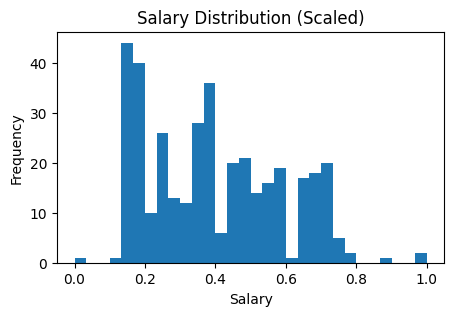

In [33]:
plt.figure(figsize=(5,3))
plt.hist(df['Salary'], bins=30)
plt.title("Salary Distribution (Scaled)")
plt.xlabel("Salary")
plt.ylabel("Frequency")
plt.show()

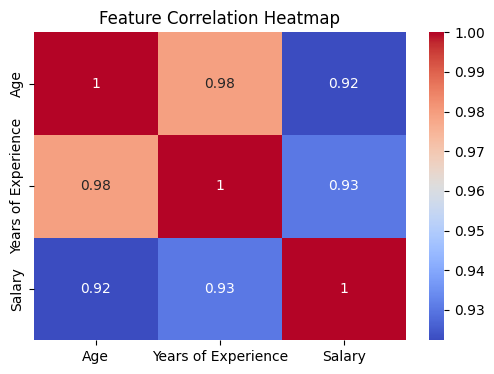

In [34]:
import seaborn as sns

plt.figure(figsize=(6,4))
sns.heatmap(
    df[['Age','Years of Experience','Salary']].corr(),
    annot=True, cmap='coolwarm'
)
plt.title("Feature Correlation Heatmap")
plt.show()


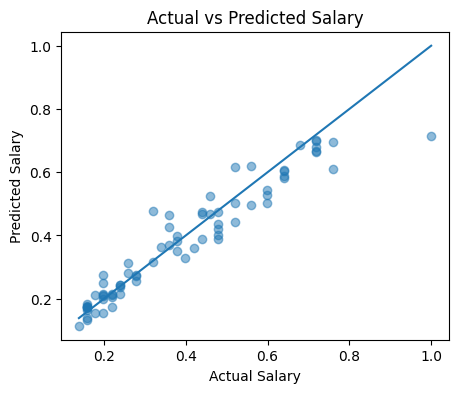

In [35]:
plt.figure(figsize=(5,4))
plt.scatter(y_test_orig, y_pred_orig, alpha=0.5)
plt.plot(
    [y_test_orig.min(), y_test_orig.max()],
    [y_test_orig.min(), y_test_orig.max()]
)
plt.xlabel("Actual Salary")
plt.ylabel("Predicted Salary")
plt.title("Actual vs Predicted Salary")
plt.show()


## Create LSTM Sequences

In [36]:
def create_lstm_sequences(data, seq_len=5):  # function to create sequences for LSTM input
    X, y = [], []  # define input and output(target) lists
    data = data.sort_values('Years of Experience')  # sort data by experience to maintain temporal order
     
    for i in range(len(data) - seq_len):  # create sequences of specified length
        seq = data.iloc[i:i+seq_len][['Age','Years of Experience','Salary']].values  # input features
        # predicting salary based on previous data
        target = data.iloc[i+seq_len]['Salary'] # target is the salary after the sequence
        X.append(seq)  # append sequence to input list
        y.append(target) # append target to output list
    
    return np.array(X), np.array(y)  # convert lists to numpy arrays for model efficiency & compatibility

X, y = create_lstm_sequences(df, seq_len=5) # create sequences with length 5
X.shape, y.shape

((368, 5, 3), (368,))

## Train/Test Split

In [37]:
# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(  
    X, y, test_size=0.2, random_state=42 # random_state for reproducibility
)

## Build Keras LSTM Model

In [38]:
# building the LSTM model by stacking layers and specifying parameters and activations 
model = Sequential([  # sequential model for stacking layers
    LSTM(64, activation='tanh', return_sequences=False, input_shape=(5,3)),  # LSTM layer with 64 neurons and tanh activation
    Dense(32, activation='relu'),  # Dense layer with 32 neurons and ReLU activation
    Dense(1)  # Output layer for regression (predicting salary)
])

model.compile(optimizer='adam', loss='mse')  #adam optimizer for efficient training, mse loss for regression tasks
model.summary() 

c:\Users\Arwa\New folder\project.py\venv\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_1 (LSTM)                   │ (None, 64)             │        17,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 19,521 (76.25 KB)

 Trainable params: 19,521 (76.25 KB)

 Non-trainable params: 0 (0.00 B)

## Train Model

In [39]:
# Train the model on the training data
history = model.fit(  
    X_train, y_train,  
    epochs=50,# epochs for training iterations
    batch_size=32, # batch size for weight updates and gradient descent
    validation_split=0.2, #out of training data, 20% used for validation to monitor overfitting
    verbose=1,# verbosity means progress output during training
    callbacks=[tf.keras.callbacks.EarlyStopping(  # early stopping to prevent overfitting
                                            patience=10,  # number of epochs with no improvement after which training will be stopped
                                            restore_best_weights=True)]   # restore best weights after stopping
    )

Epoch 1/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 2s 36ms/step - loss: 0.0837 - val_loss: 0.0164
Epoch 2/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0081 - val_loss: 0.0153
Epoch 3/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0110 - val_loss: 0.0074
Epoch 4/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0058 - val_loss: 0.0095
Epoch 5/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0060 - val_loss: 0.0075
Epoch 6/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0052 - val_loss: 0.0076
Epoch 7/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0054 - val_loss: 0.0074
Epoch 8/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0050 - val_loss: 0.0074
Epoch 9/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0050 - val_loss: 0.0073
Epoch 10/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0051 - val_loss: 0.0072
Epoch 11/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0050 - val_loss: 0.0073
Epoch 12/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0051 - val_loss: 0.0074
Epoch 

## Evaluate Model

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step
RMSE: 0.00355237908335133
MAE: 0.04138790909700494
R2 Score: 0.9124494598950874
Explained Variance Score: 0.9168034805034426
Tolerance-based Accuracy: 0.6216216216216216
MAPE (%): 10.823489278799418
Directional Accuracy: 0.8767123287671232


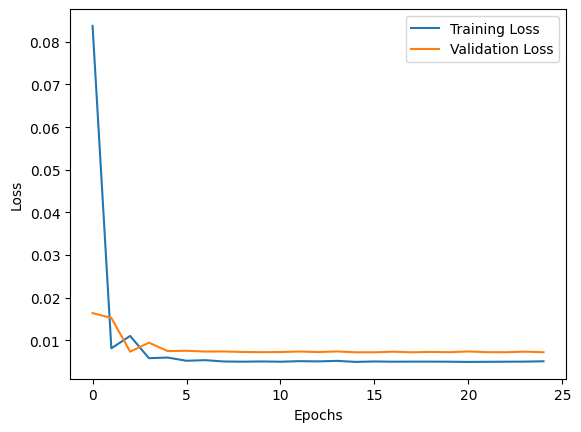

In [40]:
#  Predictions 
from sklearn.metrics import explained_variance_score
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score



y_pred = model.predict(X_test)

#Scalers


salary_scaler = MinMaxScaler()
salary_scaler.fit(df[['Salary']])

# Inverse transform predictions and true values
y_pred_orig = salary_scaler.inverse_transform(y_pred)
y_test_orig = salary_scaler.inverse_transform(y_test.reshape(-1, 1))


# Regression Metrics 


rmse = mean_squared_error(y_test_orig, y_pred_orig)
mae = mean_absolute_error(y_test_orig, y_pred_orig)
r2 = r2_score(y_test_orig, y_pred_orig)
evs = explained_variance_score(y_test_orig, y_pred_orig)


#Tolerance-based Accuracy
tolerance = 0.10   # 10% tolerance
accuracy = np.mean(
    np.abs(y_test_orig - y_pred_orig) <= tolerance * y_test_orig
)


# MAPE 
mape = np.mean(
    np.abs((y_test_orig - y_pred_orig) / y_test_orig)
) * 100


# Directional Accuracy (LSTM-friendly) 
directional_accuracy = np.mean(
    np.sign(np.diff(y_test_orig.flatten())) ==
    np.sign(np.diff(y_pred_orig.flatten()))
)


#Print Results 
print("RMSE:", rmse)
print("MAE:", mae)
print("R2 Score:", r2)
print("Explained Variance Score:", evs)
print("Tolerance-based Accuracy:", accuracy)
print("MAPE (%):", mape)
print("Directional Accuracy:", directional_accuracy)


# Convergence (Training vs Validation Loss)


plt.figure()
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.show()

## Plot Predictions

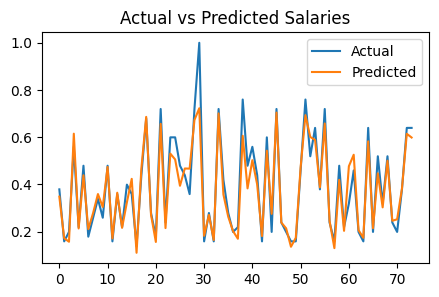

In [41]:
# plot actual vs predicted salaries for visual comparison
plt.figure(figsize=(5,3))   # figure size
plt.plot(y_test_orig[:100], label='Actual')  # plot first 100 actual salaries
plt.plot(y_pred_orig[:100], label='Predicted')  # plot first 100 predicted salaries
plt.legend()   # legend to differentiate actual vs predicted
plt.title('Actual vs Predicted Salaries')  # title of the plot
plt.show()   # display